In [1]:
# importing the datasets, make sure to have them uploaded.
import pandas as pd
import re

# Function to remove non-ASCII characters from text
def clean_text(text):
    if isinstance(text, str):
        # Encode to ascii, ignoring errors (removes non-ascii), then decode back to string
        return text.encode('ascii', 'ignore').decode('ascii')
    return text

books = pd.read_csv("books_enriched.csv", encoding='utf-8')
ratings = pd.read_csv("ratings.csv", encoding='utf-8')

In [2]:
# i truncated some of the columns that i deemed not as important
books = books[[
    "book_id",
    "title",
    "authors",
    "description",
    "genres",
    'ratings_1',
    'ratings_2',
    'ratings_3',
    'ratings_4',
    'ratings_5',
    "average_rating",
    "ratings_count",
    "pages",
    "original_publication_year",
    "image_url"
]]

In [3]:
# applied simple preprocessing
books["description"] = books["description"].fillna('')
books["genres"] = books["genres"].fillna('')
books["authors"] = books["authors"].fillna('')

Cleaning Data

In [4]:
initial_book_count = len(books)
print(f"Initial number of books: {len(books)}")

# 1. Apply clean_text function to relevant string columns
for col in ['title', 'authors', 'description', 'genres']:
    books[col] = books[col].apply(clean_text)

books = books[~books['title'].str.contains('boxed set|collection|omnibus|vol\.|volume', case=False, na=False)]

# 2. Convert numerical columns to appropriate types and handle errors/missing values
# average_rating
books['average_rating'] = pd.to_numeric(books['average_rating'], errors='coerce')
# ratings_count
books['ratings_count'] = pd.to_numeric(books['ratings_count'], errors='coerce').astype('Int64') # Use Int64 for nullable integer
# pages
books['pages'] = pd.to_numeric(books['pages'], errors='coerce').astype('Int64') # Use Int64 for nullable integer
# original_publication_year
books['original_publication_year'] = pd.to_numeric(books['original_publication_year'], errors='coerce').astype('Int64')

# 3. Drop rows with missing values in essential columns after type conversion
# Define essential columns that cannot be null
essential_columns = ['book_id', 'title', 'authors', 'average_rating', 'ratings_count', 'pages', 'original_publication_year']
books.dropna(subset=essential_columns, inplace=True)

# 4. Re-apply pruning filters (from previous requests)
initial_pruning_count = len(books)
books = books[~books['title'].str.contains('summary', case=False, na=False)]
books = books[~books['authors'].str.contains('bookrags', case=False, na=False)]
books = books[books['pages'] >= 100] # Ensure pages are also numeric and >= 100

print(f"Number of books after cleaning and pruning: {len(books)}")
print(f"Total books removed during cleaning and pruning: {initial_book_count - len(books)}")

# Reset index after dropping rows to ensure a continuous index
books.reset_index(drop=True, inplace=True)

<>:8: SyntaxWarning: invalid escape sequence '\.'
<>:8: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_8283/2526462810.py:8: SyntaxWarning: invalid escape sequence '\.'
  books = books[~books['title'].str.contains('boxed set|collection|omnibus|vol\.|volume', case=False, na=False)]


Initial number of books: 10000
Number of books after cleaning and pruning: 9109
Total books removed during cleaning and pruning: 891


In [5]:
import re
import pandas as pd

def remove_noise(text, max_words=300):
    if pd.isna(text):
        return ""

    text = str(text)

    # =========================================================
    # CLEANING PATTERNS
    # =========================================================

    patterns = [

        # -------------------------------------------------
        # Alternate cover junk (expanded)
        # -------------------------------------------------
        r"(?:this\s+is\s+)?an?\s*alternate\s*cover\s*edition(?:\s*of)?(?:\s*(?:this\s+)?isbn)?.*?(?=\.|$|\n)",
        r"alternative\s*cover\s*edition.*?(?=\.|$)",
        r"alternate\s*cover.*?(?=\.|$)",
        r"also\s*see\s*:\s*alternate\s*cover\s*editions?.*?(?=\.|$)",
        r"you\s*can\s*find\s*an?\s*alternative?\s*cover.*?(?=\.|$)",
        r"for\s+(?:the\s+)?1st\s+printing\s+edition\s+of\s+this\s+isbn.*?(?=\.|$)",
        r"see\s+here\.?",
        r"earlier\s+cover\s+edition.*?(?=\.|$)",
        r"alternate\s+cover\s+for\s+/?\s*\d+",

        # -------------------------------------------------
        # ISBN / ASIN (expanded)
        # -------------------------------------------------
        r"\(?isbn[- ]?(?:10|13)?[:\s]?[\dXx\-]{5,}\)?",
        r"isbn13?\s*here",
        r"\b(?:asin|b0)[A-Z0-9]{8,}\b",
        r"/\s*978[\d\-]{10,}",

        # -------------------------------------------------
        # Bestseller marketing phrases (UPDATED)
        # -------------------------------------------------
        r"(?:#?\s*1\s+)?(?:new\s+york\s+times|nyt|national|international|usa\s+today|wall\s+street\s+journal|indie|world-?wide|global)\s+best\s*sellers?",
        r"(?:the\s+)?(?:instant|phenomenal|blockbuster|runaway)?\s*(?:#?\s*1\s+)?(?:new\s+york\s+times|nyt)\s+best\s*selling\s+(?:series|author|novel|book|debut)?",
        r"(?:#?\s*1\s+)?best\s*sellers?",
        r"instant\s+best\s*sellers?",
        r"best\s*selling\s+(?:series|author|novel|book|debut)",

        # -------------------------------------------------
        # Motion picture / TV / adaptation promos (UPDATED)
        # -------------------------------------------------
        r"[^.!?]*\bmajor\s+motion\s+picture[^.!?]*(?:[.!?]|$)",
        r"(?:the\s+)?(?:basis|inspiration|story|author)\s+(?:for|that|featured\s+in|behind)[^.!?]*(?:movie|film|tv\s+series|netflix)[^.!?]*(?:[.!?]|$)",
        r"(?:now|soon|currently)\s+(?:to\s+be\s+)?(?:a|in|an)[^.!?]*(?:movie|film|tv\s+series|netflix)[^.!?]*(?:[.!?]|$)",
        r"read\s+it\s+before\s+it\s+hits\s+(?:theaters?|cinemas?)[^.!?]*(?:[.!?]|$)",
        r"in\s+theaters?\s+\w+\s+\d{4}[^.!?]*(?:[.!?]|$)",

        # -------------------------------------------------
        # Edition / Cover fluff (UPDATED)
        # -------------------------------------------------
        r"[^.!?]*\brevised\s+and\s+expanded\s+edition\b[^.!?]*(?:[.!?]|$)",
        r"[^.!?]*\bincludes\s+\d+\s+new\s+pages\b[^.!?]*(?:[.!?]|$)",

        # -------------------------------------------------
        # Award / accolade boilerplate
        # -------------------------------------------------
        r"winner\s+of\s+(?:the\s+)?[^.]{0,60}(?:award|prize)[^.]*\.",
        r"(?:national\s+book\s+award|pulitzer\s+prize|booker\s+prize|hugo\s+award|nebula\s+award|edgar\s+award|newbery)[^.]*(?:winner|finalist|nominee)[^.]*\.",
        r"(?:finalist|nominee|winner)\s+for\s+(?:the\s+)?[^.]{0,60}(?:award|prize)[^.]*\.",
        r"named\s+(?:one\s+of\s+)?(?:the\s+)?best\s+(?:books?|novels?)[^.]*(?:by|of)[^.]*\.",
        r"named\s+to\s+numerous\s+state\s+reading\s+lists[^.]*\.",

        # -------------------------------------------------
        # Librarian / publisher / series notes
        # -------------------------------------------------
        r"librarian'?s?\s*note\s*:.*?(?=\.|$)",
        r"publisher'?s?\s*note\s*:.*?(?=\.|$)",
        r"also\s+see\s*:.*?(?=\.|$)",
        r"page\s+numbers?\s+source\s+isbn.*?(?=\.|$)",
        r"note\s*:\s*all\s+information\s+herein[^.]*\.",
        r"\*+[^*]+\*+",

        # -------------------------------------------------
        # Back cover / edition notes
        # -------------------------------------------------
        r"\(back\s+cover\)",
        r"\(front\s+flap\)",
        r"--this\s+text\s+refers\s+to[^.]*\.",

        # -------------------------------------------------
        # Goodreads URLs / metadata
        # -------------------------------------------------
        r"https?:\/\/\S+",
        r"www\.\S+",
        r"goodreads\.\S+",

        # -------------------------------------------------
        # Critic quotes / blurbs
        # Two patterns: double-quote and em-dash styles
        # e.g. "Hilariously funny" -- USA Today
        # e.g. Brilliant. —The New York Times
        # -------------------------------------------------
        r'"[^"]{0,120}"\s*[-—–]+\s*[A-Z][^\n"]{0,80}',
        r'[-—–]{1,2}\s*(?:the\s+)?[A-Z][a-zA-Z\s]{3,40}(?:times|post|review|journal|tribune|herald|magazine|press|weekly|daily|observer|guardian|globe|chronicle|digest)\b[^\n.]{0,60}',

        # -------------------------------------------------
        # Praise / blurb section headers
        # -------------------------------------------------
        r"praise\s+for\s+[^:]{0,60}:.*?(?=\n|\Z)",

        # -------------------------------------------------
        # Malformed leftovers
        # -------------------------------------------------
        r"\.\.+",
        r"\[\s*ACE\s*\]",
        r"ACE\s*#\d+",
        r"~\s*$",
    ]

    for pattern in patterns:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE | re.DOTALL)

    # =========================================================
    # FIX SPACING
    # =========================================================

    # FIX: Only split on clear word boundaries, not Mc/Mac/O' names
    # lowerCaseUpperCase -> lowerCase UpperCase
    # but skip Mc/Mac prefixes and O' contractions
    text = re.sub(
        r"(?<![Mm][ac]|O')([a-z])([A-Z])",
        r"\1 \2",
        text
    )

    # punctuation spacing
    text = re.sub(r"([.!?])([A-Za-z])", r"\1 \2", text)

    # remove spaces before punctuation
    text = re.sub(r"\s+([.,!?;:])", r"\1", text)

    # =========================================================
    # CLEAN UP PUNCTUATION ARTIFACTS
    # Left after regex removal, e.g:
    #   ", and"  at start  ->  "And"
    #   "( )"    empty     ->  ""
    #   " -- "   dangling  ->  " "
    #   ": "     leading   ->  ""
    # =========================================================

    # remove empty parentheses / brackets
    text = re.sub(r"\(\s*\)", " ", text)
    text = re.sub(r"\[\s*\]", " ", text)

    # remove dangling dashes (with no word on one side)
    text = re.sub(r"(?<!\w)\s*[-—–]{1,2}\s*(?!\w)", " ", text)

    # remove leading conjunctions/punctuation at sentence start
    # e.g. ", and foo" -> "foo" | ". But" already fine
    text = re.sub(r"(?:^|(?<=\.))\s*[,;:\-—–]+\s*", " ", text)

    # collapse repeated punctuation like "!!" or ",,"
    text = re.sub(r"([.,!?;:])\1+", r"\1", text)

    # normalize whitespace
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    # strip leading punctuation at the very start of the string
    text = re.sub(r"^[^A-Za-z0-9\"'(]+", "", text)

    # =========================================================
    # REMOVE DUPLICATE SENTENCES
    # =========================================================

    sentences = re.split(r'(?<=[.!?])\s+', text)
    seen = set()
    unique_sentences = []

    for sentence in sentences:
        normalized = sentence.strip().lower()
        if normalized and normalized not in seen:
            seen.add(normalized)
            unique_sentences.append(sentence.strip())

    text = " ".join(unique_sentences)

    # =========================================================
    # LIMIT DESCRIPTION LENGTH
    # =========================================================

    words = text.split()
    text = " ".join(words[:max_words])

    return text

In [6]:
# adds a column with a clean description after applying the above function
books["clean_description"] = books["description"].apply(remove_noise)

In [7]:
def deduplicate_descriptions(df, description_col="clean_description", title_col="title"):
    """
    Handles three distinct problems after cleaning:

    1. Empty descriptions   → dropped, logged separately
    2. Mismatched descriptions (diff titles, same desc) → ALL dropped, logged separately
    3. True duplicates (same title, same desc)          → First kept, rest dropped
    """
    df = df.copy()

    # ── 1. Empty descriptions ─────────────────────────────────────────────
    empty_mask = df[description_col].str.strip().eq("") | df[description_col].isna()
    empty_df = df[empty_mask][[title_col, description_col]].copy()

    non_empty_df = df[~empty_mask].copy()

    # ── 2. Identify ALL rows that share a description ─────────────────────
    # keep=False marks EVERY row that is part of a duplicate cluster
    all_dupes_mask = non_empty_df[description_col].duplicated(keep=False)
    all_dupes_df = non_empty_df[all_dupes_mask].copy()

    # Count how many unique titles are associated with each duplicated description
    title_counts = all_dupes_df.groupby(description_col)[title_col].transform('nunique')

    # ── 3. Mismatched Duplicates (Data Corruption) ────────────────────────
    # If a description belongs to >1 unique title, it's corrupted. Drop ALL.
    mismatch_mask = title_counts > 1
    mismatch_df = all_dupes_df[mismatch_mask].copy()

    # ── 4. True Duplicates (Safe to keep first) ───────────────────────────
    # If a description belongs to exactly 1 title, it's just a standard duplicate row.
    true_dupe_df = all_dupes_df[~mismatch_mask].copy()

    # Identify the ones we are actually dropping (the 2nd, 3rd, etc. occurrences)
    true_dupes_dropped_mask = true_dupe_df[description_col].duplicated(keep="first")
    true_dupes_dropped_df = true_dupe_df[true_dupes_dropped_mask].copy()

    # ── 5. Build Final Clean Dataset ──────────────────────────────────────
    # Start with non-empty, drop ALL mismatches, and drop the redundant true duplicates
    drop_indices = mismatch_df.index.union(true_dupes_dropped_df.index)
    df_clean = non_empty_df.drop(index=drop_indices).reset_index(drop=True)

    # ── Logging ───────────────────────────────────────────────────────────
    print("=" * 70)
    print(f"  EMPTY DESCRIPTIONS: {len(empty_df)} rows dropped")
    print("=" * 70)

    print("\n" + "=" * 70)
    print(f"  CORRUPT MISMATCHES (All Dropped): {len(mismatch_df)} rows")
    print("=" * 70)
    if not mismatch_df.empty:
        mismatch_df["preview"] = mismatch_df[description_col].str[:80]
        # Sort by description so you can easily see the clusters of corrupted rows
        print(mismatch_df.sort_values(description_col)[[title_col, "preview"]].to_string())

    print("\n" + "=" * 70)
    print(f"  TRUE DUPES (Extras Dropped): {len(true_dupes_dropped_df)} rows")
    print("=" * 70)

    print("\n" + "=" * 70)
    summary = {
        "original_rows":   len(df),
        "empty_dropped":   len(empty_df),
        "mismatches_dropped": len(mismatch_df),
        "true_dupes_dropped": len(true_dupes_dropped_df),
        "remaining_rows":  len(df_clean),
    }
    for k, v in summary.items():
        print(f"  {k:<25} {v}")
    print("=" * 70)

    return df_clean, summary

In [8]:
books, summary = deduplicate_descriptions(
    books,
    description_col="clean_description"
)

  EMPTY DESCRIPTIONS: 63 rows dropped

  CORRUPT MISMATCHES (All Dropped): 279 rows
                                                                                                                                         title                                                                           preview
8635                                                                                                                                        2                                                                               "2 "
8636                                                                                                               Flood Tide (Dirk Pitt, #14)                                                                              "2 "
8336                                                                                                                         How We Are Hungry  "Another""What It Means When a Crowd in a Faraway Nation Takes a Soldier Represe
8337            

In [9]:
# checks descriptions
for i, text in enumerate(books["clean_description"].sample(75), 1):
    print(f"\n--- DESCRIPTION {i} ---\n")
    print(text[:1000])


--- DESCRIPTION 1 ---

R is having a no-life crisishe is a zombie. He has no memories, no identity, and no pulse, but he is a little different from his fellow Dead. He may occasionally eat people, but hed rather be riding abandoned airport escalators, listening to Sinatra in the cozy 747 he calls home, or collecting souvenirs from the ruins of civilization. And then he meets a girl. First as his captive, then his reluctant guest, Julie is a blast of living color in Rs gray landscape, and something inside him begins to bloom. He doesn't want to eat this girlalthough she looks delicioushe wants to protect her. But their unlikely bond will cause ripples they cant imagine, and their hopeless world wont change without a fight.

--- DESCRIPTION 2 ---

Since birth, Nyx has been betrothed to the evil ruler of her kingdom-all because of a foolish bargain struck by her father. And since birth, she has been in training to kill him. With no choice but to fulfill her duty, Nyx resents her family f

In [10]:
marketing = books[
    books["clean_description"].str.contains(
        r"new york times bestseller|major motion picture|usa today bestseller|read it before",
        case=False,
        regex=True,
        na=False
    )
]

marketing[["title", "clean_description"]].head(1000)

,title,clean_description
3544,Manhunt: The 12-Day Chase for Lincoln's Killer,"A fascinating tale of murder, intrigue, and be..."


In [11]:
isbn_noise = books[
    books["clean_description"].str.contains(
        r"alternate cover|isbn|ace #",
        case=False,
        regex=True,
        na=False
    )
]

isbn_noise[["title", "clean_description"]].head(10000)

,title,clean_description
123,The Pillars of the Earth (The Kingsbridge Seri...,Ken Follett is known worldwide as the master o...
149,Emma,An alternative cover of this ISBN can be found...
344,"Throne of Glass (Throne of Glass, #1)",This is a previously published edition of ISBN...
563,Sophie's World,An alternative cover for this ISBN can be foun...
726,"Howl's Moving Castle (Howl's Moving Castle, #1)",An alternative cover for this ISBN can be foun...
3006,The Complete Stories,This is the original cover edition of ISBN: 03...
3515,Demons,(ISBN13: 9780679734512)Inspired by the true st...
4691,The Hating Game,This is a previously-published edition ISBN13:...
5297,"A Lot like Love (FBI/US Attorney, #2)",ISBN: 9780425240168 updated version found here...
6476,"Branded (Fall of Angels, #1)",Alternate editions for this ISBN can be found ...


In [12]:
books.head(5)["clean_description"]

,clean_description
0,WINNING MEANS FAME AND FORTUNE. LOSING MEANS C...
1,Harry Potter's life is miserable. His parents ...
2,About three things I was absolutely positive. ...
3,The unforgettable novel of a childhood in a sl...
4,"Scott Fitzgerald's third book, stands as the s..."


Data Visualization

In [ ]:
print("--- 1. High-Level Dataset Overview ---")
print(f"Total Books: {len(books):,}")
print(f"Total Individual Ratings: {len(ratings):,}")
print(f"Total Unique Users: {ratings['user_id'].nunique():,}")

print("\n--- 2. Book Statistics ---")
# Global average of the 'average_rating' column
print(f"Global Average Book Rating: {books['average_rating'].mean():.2f} / 5.0")
# Using median for ratings count is better than mean because highly popular books skew the average
print(f"Median Ratings per Book: {books['ratings_count'].median():,.0f}")
print(f"Maximum Ratings on a Single Book: {books['ratings_count'].max():,.0f}")

print("\n--- 3. User Statistics ---")
print(f"Average Rating Given by Users: {ratings['rating'].mean():.2f} / 5.0")

# Calculate how active the users are
ratings_per_user = ratings.groupby('user_id').size()
print(f"Average Ratings given per User: {ratings_per_user.mean():.0f}")
print(f"Median Ratings given per User: {ratings_per_user.median():.0f}")


#Sparsity
# Sparsity = 1 - (Actual Ratings / Possible Ratings)
possible_ratings = len(books) * ratings['user_id'].nunique()
actual_ratings = len(ratings)
sparsity = 1 - (actual_ratings / possible_ratings)

print("\n--- 4. Data Sparsity ---")
print(f"Matrix Sparsity: {sparsity:.4%}")
print("(A sparsity over 99% is normal for recommendation systems, but means we might need to handle 'cold starts')")

--- 1. High-Level Dataset Overview ---
Total Books: 8,767
Total Individual Ratings: 5,976,479
Total Unique Users: 53,424

--- 2. Book Statistics ---
Global Average Book Rating: 3.99 / 5.0
Median Ratings per Book: 22,003
Maximum Ratings on a Single Book: 4,780,653

--- 3. User Statistics ---
Average Rating Given by Users: 3.92 / 5.0
Average Ratings given per User: 112
Median Ratings given per User: 111

--- 4. Data Sparsity ---
Matrix Sparsity: 98.7240%
(A sparsity over 99% is normal for recommendation systems, but means we might need to handle 'cold starts')


In [12]:
!pip install "numpy<2.0" --force-reinstall

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.

--- 1. Univariate Analysis: Distributions ---


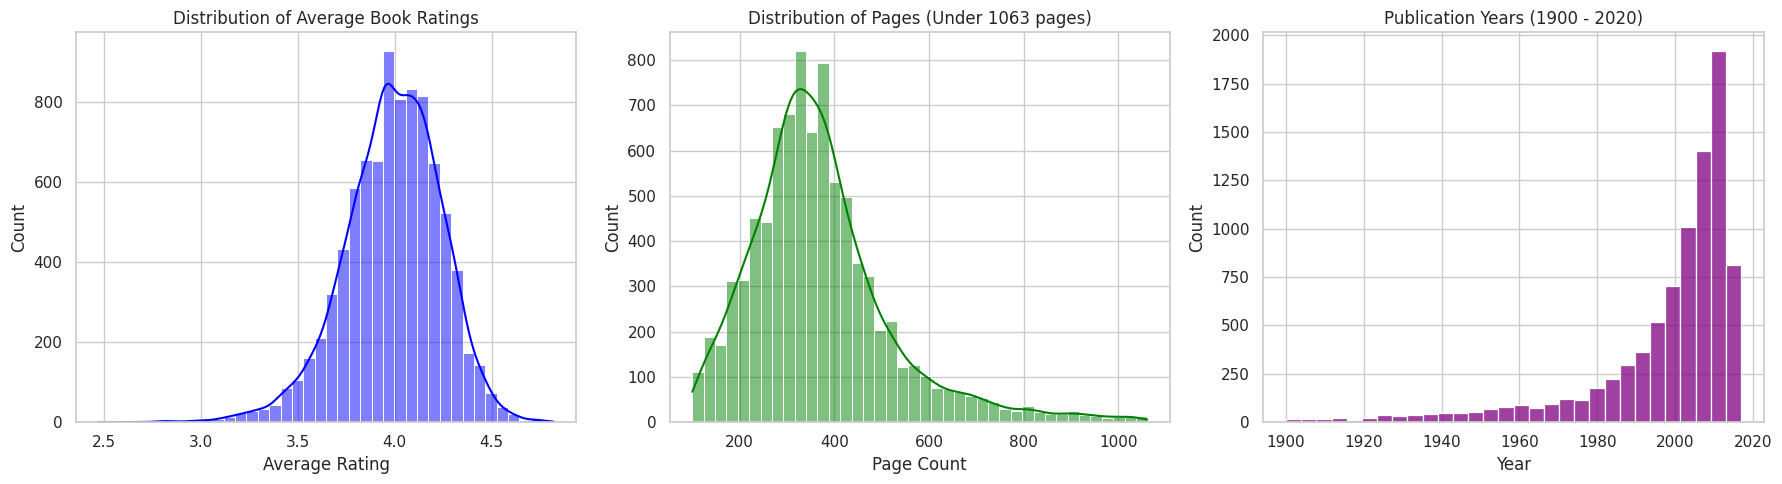

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional plotting style
sns.set_theme(style="whitegrid", palette="muted")

print("--- 1. Univariate Analysis: Distributions ---")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1A: Distribution of Average Ratings
sns.histplot(books['average_rating'], bins=40, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Average Book Ratings')
axes[0].set_xlabel('Average Rating')

# 1B: Distribution of Pages (filtering extreme outliers for readability)
# Assuming 99th percentile captures standard books without encyclopedia outliers
q99_pages = books['pages'].quantile(0.99)
sns.histplot(books[books['pages'] < q99_pages]['pages'], bins=40, kde=True, ax=axes[1], color='green')
axes[1].set_title(f'Distribution of Pages (Under {int(q99_pages)} pages)')
axes[1].set_xlabel('Page Count')

# 1C: Publication Year (Focusing on modern era: 1900 to present)
modern_books = books[(books['original_publication_year'] >= 1900) & (books['original_publication_year'] <= 2020)]
sns.histplot(modern_books['original_publication_year'], bins=30, kde=False, ax=axes[2], color='purple')
axes[2].set_title('Publication Years (1900 - 2020)')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.show()

--- 2. Categorical & Popularity Analysis ---


/tmp/ipykernel_3043/49736405.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=author_counts.values, y=author_counts.index, ax=axes[0], palette='viridis')
/tmp/ipykernel_3043/49736405.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='average_rating', y='title', data=popular_books, ax=axes[1], palette='magma')


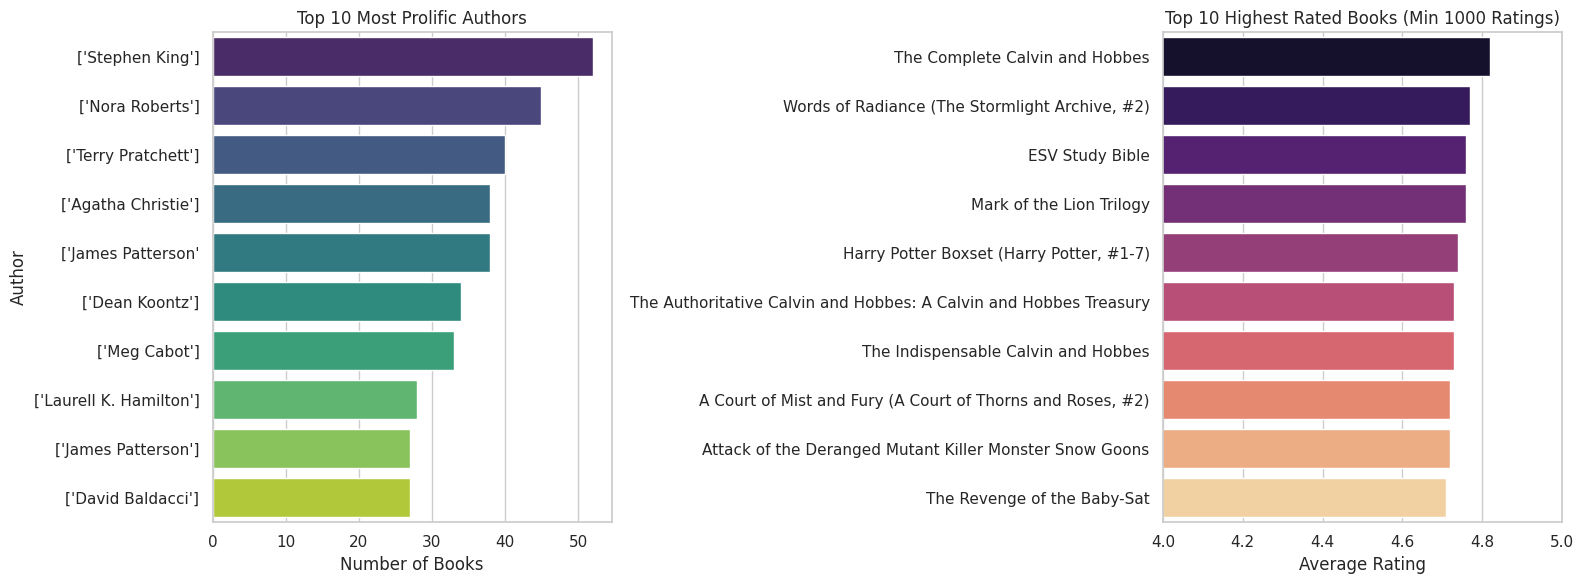

In [ ]:
print("--- 2. Categorical & Popularity Analysis ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2A: Top 10 Most Prolific Authors in the dataset
# Splitting authors in case there are multiple authors separated by commas
author_counts = books['authors'].str.split(',').explode().str.strip().value_counts().head(10)

sns.barplot(x=author_counts.values, y=author_counts.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Most Prolific Authors')
axes[0].set_xlabel('Number of Books')
axes[0].set_ylabel('Author')

# 2B: Top 10 Highest Rated Books (with Bayesian/Bayesian-like smoothing constraint)
# Only consider books with at least 1,000 ratings to filter out 5.0 ratings with 1 review
popular_books = books[books['ratings_count'] > 1000].sort_values('average_rating', ascending=False).head(10)

sns.barplot(x='average_rating', y='title', data=popular_books, ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Highest Rated Books (Min 1000 Ratings)')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('')
axes[1].set_xlim(4.0, 5.0) # Zoom in to see the differences clearly

plt.tight_layout()
plt.show()

--- 3. Bivariate Analysis & Correlation ---


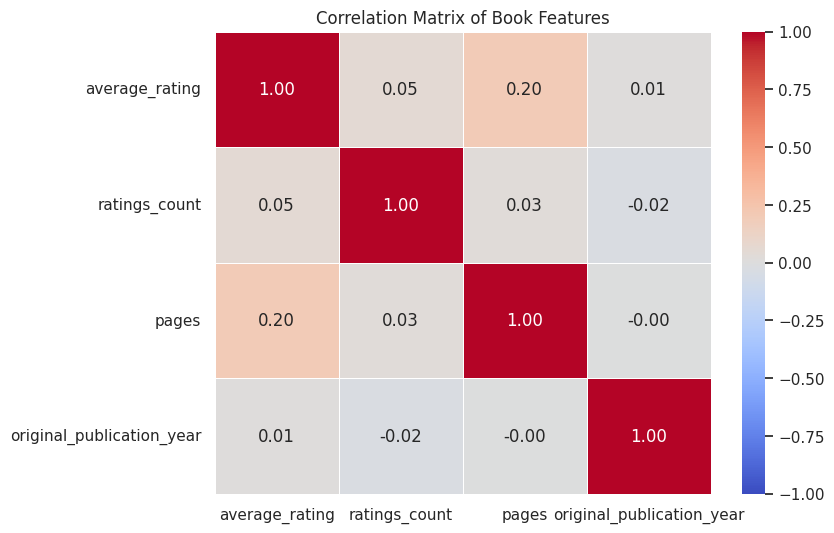

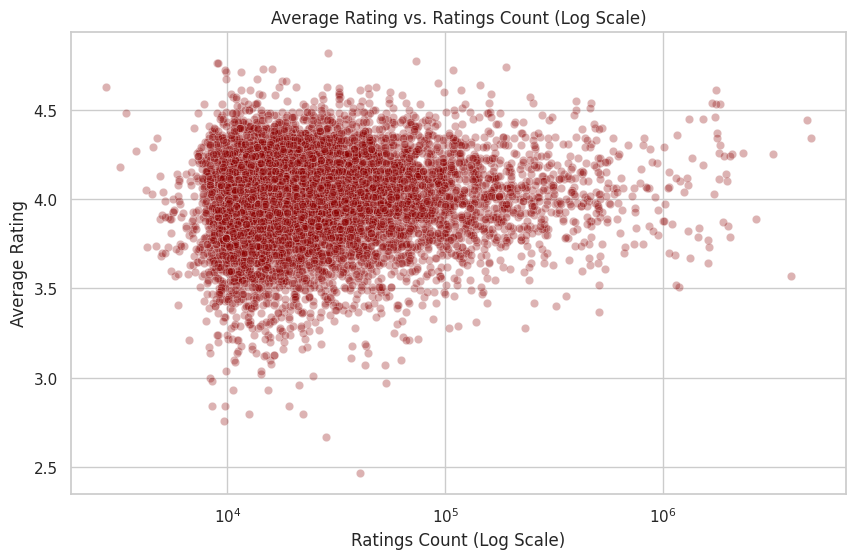

In [ ]:
print("--- 3. Bivariate Analysis & Correlation ---")

# 3A: Correlation Heatmap
# Select only numerical columns for correlation
num_cols = ['average_rating', 'ratings_count', 'pages', 'original_publication_year']
corr_matrix = books[num_cols].astype(float).corr() # Ensure float for correlation calculation

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Book Features')
plt.show()

# 3B: Scatter plot: Ratings Count vs. Average Rating
# Does having more ratings push the average rating up or down?
plt.figure(figsize=(10, 6))
# Using a log scale for x-axis because ratings count is usually a "long-tail" distribution
sns.scatterplot(x='ratings_count', y='average_rating', data=books, alpha=0.3, color='darkred')
plt.xscale('log')
plt.title('Average Rating vs. Ratings Count (Log Scale)')
plt.xlabel('Ratings Count (Log Scale)')
plt.ylabel('Average Rating')
plt.show()

--- 4. User-Item Interactions (Ratings Data) ---


/tmp/ipykernel_3043/3168348980.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, ax=axes[0], palette='YlGnBu')


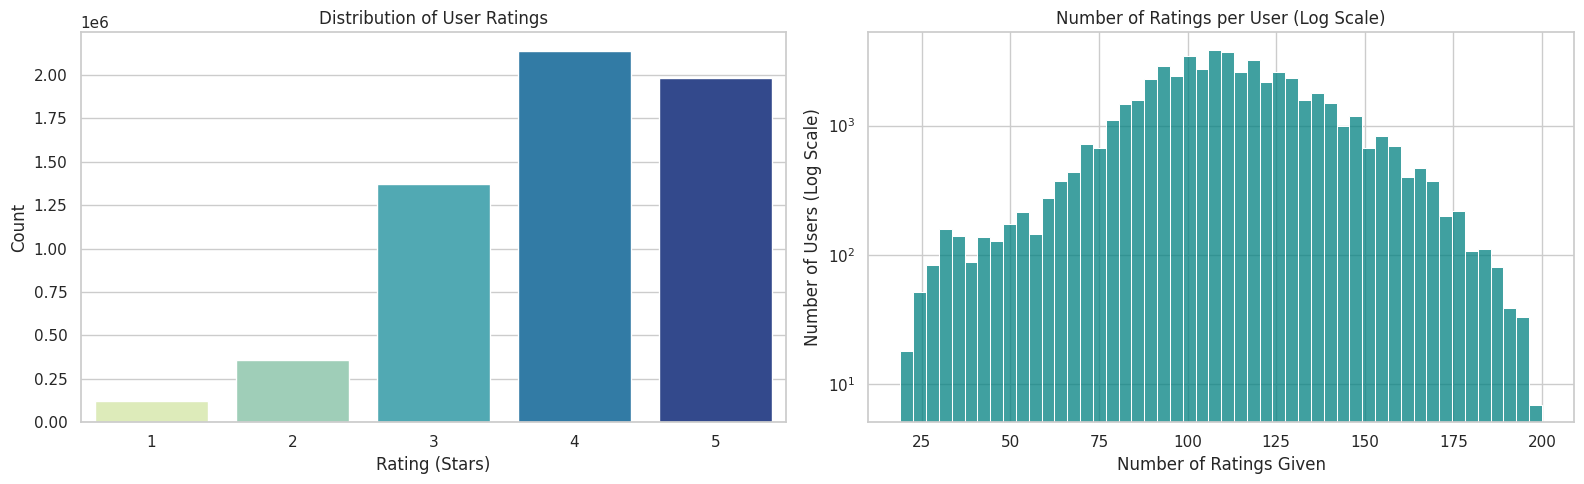


Matrix Sparsity: 98.8813% (Typical for recommendation systems)


In [ ]:
print("--- 4. User-Item Interactions (Ratings Data) ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 4A: Distribution of individual ratings (1-5 stars)
sns.countplot(x='rating', data=ratings, ax=axes[0], palette='YlGnBu')
axes[0].set_title('Distribution of User Ratings')
axes[0].set_xlabel('Rating (Stars)')
axes[0].set_ylabel('Count')

# 4B: Ratings per User (Sparsity check)
ratings_per_user = ratings.groupby('user_id').size()
sns.histplot(ratings_per_user, bins=50, ax=axes[1], color='teal')
axes[1].set_yscale('log') # Log scale because most users rate few books, few users rate many
axes[1].set_title('Number of Ratings per User (Log Scale)')
axes[1].set_xlabel('Number of Ratings Given')
axes[1].set_ylabel('Number of Users (Log Scale)')

plt.tight_layout()
plt.show()

# Print quick sparsity metric
total_possible_interactions = ratings['user_id'].nunique() * ratings['book_id'].nunique()
actual_interactions = len(ratings)
sparsity = 1 - (actual_interactions / total_possible_interactions)
print(f"\nMatrix Sparsity: {sparsity:.4%} (Typical for recommendation systems)")

EDA Done

Feature Engineering

In [14]:
# creating book_age column
CURRENT_YEAR = 2026

books['book_age'] = (
    CURRENT_YEAR -
    books['original_publication_year']
)

books['book_age'] = books['book_age'].fillna(
    books['book_age'].median()
)

In [15]:
# Weighted Popularity score
books['popularity_score'] = (
    books['average_rating'] *
    np.log1p(books['ratings_count'])
)

In [16]:
# Genre Count
books['genre_count'] = (
    books['genres']
    .fillna('')
    .apply(
        lambda x: 0 if x == ''
        else len(x.split(','))
    )
)

In [17]:
# Positivity Ratio
books['positive_ratio'] = (
    (books['ratings_4'] + books['ratings_5']) /
    books['ratings_count'].replace(0, 1)
)

In [18]:
# Controversy Score to deal with polarized reviews
books['controversy_score'] = (
    (books['ratings_1'] + books['ratings_5']) /
    books['ratings_count']
)

In [19]:
# Author popularity
author_popularity = (
    books.groupby('authors')['ratings_count']
    .mean()
)

books['author_popularity'] = np.log1p(
    books['authors']
    .map(author_popularity)
)

In [20]:
# added another feature (column) that includes the title, author, genres and description all together, so that it's all sent to a transformer model
# the whole model below this cell depends on this column solely, as thus there are some quirks attached to it.
books["features"] = (
    books["title"] + " " +
    books["title"] + " " +
    books["authors"] + " " +
    books["genres"] + " " +
    books["genres"] + " " +
    books["genres"] + " " +
    books["description"].str[:300]
)

Normalize some columns

In [21]:
# Highly skewed ratings count, thus applying log transform
books['ratings_count_log'] = np.log1p(books['ratings_count'])

In [22]:
#Normalizing these values
from sklearn.preprocessing import StandardScaler

cols = [
    'average_rating',
    'pages',
    'book_age',
    'ratings_count_log',
    'popularity_score',
    'genre_count',
    'positive_ratio',
    'controversy_score',
    'author_popularity'
]

# Create new column names for the scaled values
scaled_cols = [c + '_scaled' for c in cols]

scaler = StandardScaler()

# Fit and transform, but save into the new columns
books[scaled_cols] = scaler.fit_transform(books[cols])

=================================== beginning of model training by encoding the column "features' =============================

In [23]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

embeddings = model.encode(
    books["features"].tolist(),
    show_progress_bar=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/274 [00:00<?, ?it/s]

In [24]:
pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 30.9 MB/s eta 0:00:00


In [25]:
import faiss

embedding_matrix = np.array(
    embeddings,
    dtype=np.float32
)

faiss_index = faiss.IndexFlatL2(
    embedding_matrix.shape[1]
)

faiss_index.add(embedding_matrix)

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("Calculating TF-IDF Sparse Embeddings...")
# Initialize TF-IDF Vectorizer
# We use stop_words='english' to ignore common words and focus on specific terms like 'grimdark'
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=15000)

# Fit and transform the features column
tfidf_matrix = tfidf_vectorizer.fit_transform(books["features"])

print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")
print("Sparse Embeddings ready!")

Calculating TF-IDF Sparse Embeddings...
TF-IDF Matrix shape: (8767, 15000)
Sparse Embeddings ready!


In [27]:
# ─────────────────────────────────────────────────────────────────
# 1A. DENSE SEMANTIC EMBEDDINGS  (SentenceTransformer → FAISS)
# Already computed above the separator: `embeddings`, `embedding_matrix`, `faiss_index`
# We normalise the matrix so FAISS inner-product ≈ cosine similarity.
# ─────────────────────────────────────────────────────────────────

# L2-normalise so that inner product == cosine similarity
embedding_matrix_norm = embedding_matrix.copy()
faiss.normalize_L2(embedding_matrix_norm)

# Replace the flat L2 index with a cosine (inner-product) index
dense_index = faiss.IndexFlatIP(embedding_matrix_norm.shape[1])
dense_index.add(embedding_matrix_norm)

print(f"Dense index ready  — {dense_index.ntotal:,} vectors  dim={embedding_matrix_norm.shape[1]}")

Dense index ready  — 8,767 vectors  dim=384


In [28]:
# ─────────────────────────────────────────────────────────────────
# 1B. SPARSE TF-IDF EMBEDDINGS
# Already computed above the separator: `tfidf_matrix`, `tfidf_vectorizer`
# We just verify shape here.
# ─────────────────────────────────────────────────────────────────
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
# Expected: (n_books, 15000)

TF-IDF matrix shape: (8767, 15000)


In [29]:
# ─────────────────────────────────────────────────────────────────
# 1C. NUMERICAL / ENGINEERED FEATURES MATRIX
# We already StandardScaler-normalised these columns above the separator.
# Stack them into a dense numpy matrix so cosine_similarity works on them.
# ─────────────────────────────────────────────────────────────────


numerical_matrix = books[scaled_cols].fillna(0).values.astype(np.float32)
print(f"Numerical matrix shape: {numerical_matrix.shape}")

Numerical matrix shape: (8767, 9)


In [30]:
user_counts = ratings["user_id"].value_counts()

active_users = user_counts[
    user_counts >= 10
].index

ratings = ratings[
    ratings["user_id"].isin(active_users)
]

In [31]:
book_counts = ratings["book_id"].value_counts()

popular_books = book_counts[
    book_counts >= 10
].index

ratings = ratings[
    ratings["book_id"].isin(popular_books)
]

In [32]:
merged = ratings.merge(
    books,
    on="book_id",
    how="inner"
)

In [ ]:
print(pd.DataFrame(merged).head(10))

   user_id  book_id  rating  \
0        1      258       5   
1        2     4081       4   
2        2      260       5   
3        2     9296       5   
4        2     2318       3   
5        2       26       4   
6        2       33       4   
7        2      301       5   
8        2     2686       5   
9        2     8519       5   

                                                                                             title  \
0                                    The Shadow of the Wind (The Cemetery of Forgotten Books,  #1)   
1                                                                           I am Charlotte Simmons   
2                                                          How to Win Friends and Influence People   
3                                      The Drama of the Gifted Child: The Search for the True Self   
4                            The Millionaire Next Door: The Surprising Secrets of Americas Wealthy   
5                                             

In [42]:
# ─────────────────────────────────────────────────────────────────
# 1D. UNIFIED CONTENT SCORE
#
# Given a list of book indices (row positions in `books`),
# returns a dict: { book_id -> content_score [0..1] }
#
# Weights:
#   dense_weight    = 0.40  (semantic understanding)
#   tfidf_weight    = 0.40  (keyword / genre precision)
#   numeric_weight  = 0.20  (popularity, age, controversy, etc.)
# ─────────────────────────────────────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

DENSE_W   = 0.40
TFIDF_W   = 0.40
NUMERIC_W = 0.20

# How many nearest neighbours to pull from FAISS per input book
FAISS_TOPK = 40


def get_content_scores(input_indices, exclude_book_ids):
    """
    Parameters
    ----------
    input_indices   : list[int]   — positional row indices in `books`
    exclude_book_ids: set         — book_ids to exclude (the inputs themselves)

    Returns
    -------
    dict { book_id -> float }  — raw (unnormalised) content score
    """
    # ── Average query vectors across all input books ──────────────
    # Dense
    mean_dense = embedding_matrix_norm[input_indices].mean(axis=0, keepdims=True).astype(np.float32)
    faiss.normalize_L2(mean_dense)

    # TF-IDF (sparse → dense mean)
    mean_tfidf = np.asarray(tfidf_matrix[input_indices].mean(axis=0))  # (1, vocab)

    # Numerical
    mean_numeric = numerical_matrix[input_indices].mean(axis=0, keepdims=True)  # (1, n_feats)

    # ── Dense: FAISS search returns cosine similarities ───────────
    sims_dense_vals, sims_dense_idx = dense_index.search(mean_dense, FAISS_TOPK + len(input_indices))
    # sims_dense_vals shape: (1, FAISS_TOPK)
    dense_scores = {}  # candidate_row_idx -> score
    for sim, row_idx in zip(sims_dense_vals[0], sims_dense_idx[0]):
        bid = books.iloc[row_idx]["book_id"]
        if bid not in exclude_book_ids:
            dense_scores[bid] = float(sim)          # cosine sim ∈ [-1, 1]

    # Union of candidates from FAISS
    candidate_ids = list(dense_scores.keys())
    if not candidate_ids:
        return {}

    # Map book_id → row index for matrix slicing
    bid_to_row = {books.iloc[i]["book_id"]: i for i in range(len(books))}
    cand_rows  = [bid_to_row[bid] for bid in candidate_ids]

    # ── TF-IDF cosine similarities ────────────────────────────────
    cand_tfidf = tfidf_matrix[cand_rows]                         # sparse (n_cand, vocab)
    tfidf_sims = cosine_similarity(mean_tfidf, cand_tfidf)[0]    # (n_cand,)

    # ── Numerical cosine similarities ────────────────────────────
    cand_numeric  = numerical_matrix[cand_rows]                  # (n_cand, n_feats)
    numeric_sims  = cosine_similarity(mean_numeric, cand_numeric)[0]  # (n_cand,)

    # ── Combine ───────────────────────────────────────────────────
    combined = {}
    for i, bid in enumerate(candidate_ids):
        d = dense_scores.get(bid, 0.0)
        t = float(tfidf_sims[i])
        n = float(numeric_sims[i])
        combined[bid] = DENSE_W * d + TFIDF_W * t + NUMERIC_W * n

    return combined


print("get_content_scores() defined.")

get_content_scores() defined.


In [43]:
# ─────────────────────────────────────────────────────────────────
# 2A. BUILD SPARSE USER–ITEM RATING MATRIX
#
# Rows = users, Columns = books (using integer positions, not raw IDs)
# Values = rating (1-5).  Unrated = 0.
#
# We work with only the filtered `ratings` df (active users, popular books)
# that was already computed above the separator.
# ─────────────────────────────────────────────────────────────────
from scipy.sparse import csr_matrix
import pandas as pd
import numpy as np

# Build integer encodings so the matrix has contiguous indices
all_user_ids = ratings["user_id"].unique()
all_book_ids = ratings["book_id"].unique()

user_to_idx = {uid: i for i, uid in enumerate(all_user_ids)}
book_to_idx = {bid: i for i, bid in enumerate(all_book_ids)}
idx_to_book = {i: bid for bid, i in book_to_idx.items()}

n_users = len(all_user_ids)
n_books_cf = len(all_book_ids)

row_arr  = ratings["user_id"].map(user_to_idx).values
col_arr  = ratings["book_id"].map(book_to_idx).values
data_arr = ratings["rating"].values.astype(np.float32)

user_item_matrix = csr_matrix(
    (data_arr, (row_arr, col_arr)),
    shape=(n_users, n_books_cf)
)

print(f"User–Item matrix: {n_users:,} users  ×  {n_books_cf:,} books")
print(f"Non-zero entries: {user_item_matrix.nnz:,}")

User–Item matrix: 53,424 users  ×  9,999 books
Non-zero entries: 5,976,471


In [44]:
# ─────────────────────────────────────────────────────────────────
# 2B. USER PROFILE VECTOR
#
# A "query user" is defined by the books they liked (the titles they
# provided as input).  We synthesise their rating vector by giving
# those books a rating of 5.0, everything else 0.
#
# Then we find the K most similar real users (cosine similarity on
# the sparse rating matrix) and aggregate their ratings for every
# candidate book as a weighted mean.
# ─────────────────────────────────────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
from scipy.sparse import csr_matrix
import numpy as np

CF_NEIGHBOURS = 50   # how many similar users to aggregate over
CF_MIN_NEIGHBOURS = 5  # minimum needed to trust the CF score


def build_query_user_vector(liked_book_ids):
    """
    Build a (1, n_books_cf) sparse vector for the query user.
    Books in liked_book_ids that appear in the CF index get rating=5.0.
    """
    col_indices, values = [], []
    for bid in liked_book_ids:
        if bid in book_to_idx:
            col_indices.append(book_to_idx[bid])
            values.append(5.0)
    if not col_indices:
        return None
    return csr_matrix(
        (values, ([0] * len(col_indices), col_indices)),
        shape=(1, n_books_cf)
    )


def get_cf_scores(liked_book_ids, candidate_book_ids):
    """
    Parameters
    ----------
    liked_book_ids    : list[int]  — book_ids the user said they like
    candidate_book_ids: list[int]  — book_ids we want CF scores for

    Returns
    -------
    dict { book_id -> float [0..1] }  — CF score (0 if not enough neighbours)
    float                             — cf_weight to apply (0.0 if CF unreliable)
    """
    query_vec = build_query_user_vector(liked_book_ids)
    if query_vec is None:
        return {}, 0.0

    # Cosine similarity between query user and every real user
    # Result shape: (1, n_users)
    similarities = cos_sim(query_vec, user_item_matrix)[0]  # (n_users,)

    # Pick the top-K neighbours (exclude exact zeros — no overlap)
    top_k_idx = np.argsort(similarities)[::-1][:CF_NEIGHBOURS]
    top_k_idx = [i for i in top_k_idx if similarities[i] > 0]

    if len(top_k_idx) < CF_MIN_NEIGHBOURS:
        # Not enough similar users → CF unreliable, fall back to content only
        return {}, 0.0

    top_sims   = np.array([similarities[i] for i in top_k_idx])   # (k,)
    neighbour_ratings = user_item_matrix[top_k_idx, :]             # (k, n_books_cf)

    # Weighted mean rating across neighbours for each candidate book
    cf_scores = {}
    for bid in candidate_book_ids:
        if bid not in book_to_idx:
            cf_scores[bid] = 0.0
            continue
        col = book_to_idx[bid]
        # Ratings that neighbours gave this book (0 = not rated)
        ratings_col = neighbour_ratings[:, col].toarray().flatten()  # (k,)
        rated_mask  = ratings_col > 0
        if rated_mask.sum() == 0:
            cf_scores[bid] = 0.0
        else:
            # Weighted average; normalise to [0, 1]
            w = top_sims[rated_mask]
            r = ratings_col[rated_mask]
            cf_scores[bid] = float(np.dot(w, r) / (w.sum() * 5.0 + 1e-9))

    # cf_weight proportional to how many candidates have neighbour coverage
    covered = sum(1 for v in cf_scores.values() if v > 0)
    coverage_ratio = covered / max(len(candidate_book_ids), 1)
    # Scale from 0.0 (no coverage) to 0.5 (full 50% weight when coverage is high)
    cf_weight = 0.5 * coverage_ratio

    return cf_scores, cf_weight


print("get_cf_scores() defined.")

get_cf_scores() defined.


In [45]:
# ─────────────────────────────────────────────────────────────────
# 3A. QUALITY FILTERS
# Applied after scoring to remove low-quality candidates.
# ─────────────────────────────────────────────────────────────────
import re

QUALITY_MIN_RATING       = 3.8
QUALITY_MIN_RATINGS_COUNT = 500
QUALITY_MIN_PAGES        = 100


def passes_quality_filter(book_row):
    """Return True if the book meets minimum quality thresholds."""
    if book_row["average_rating"] < QUALITY_MIN_RATING:
        return False
    if book_row["ratings_count"] < QUALITY_MIN_RATINGS_COUNT:
        return False
    if book_row["pages"] < QUALITY_MIN_PAGES:
        return False
    if re.search(r'summary|bookrags', book_row["title"] + book_row["authors"], re.IGNORECASE):
        return False
    if re.search(r'#([2-9]|[1-9]\d+)', book_row["title"]):
        return False
    return True


# Pre-compute quality mask so we never score a bad book
_quality_mask = books.apply(passes_quality_filter, axis=1)
_quality_book_ids = set(books.loc[_quality_mask, "book_id"])

print(f"Books that pass quality filter: {len(_quality_book_ids):,} / {len(books):,}")

Books that pass quality filter: 4,709 / 8,767


In [46]:
# ─────────────────────────────────────────────────────────────────
# 3B. DIVERSITY FILTER
# Caps how many books from the same author / primary genre appear
# in the final top-K, and removes spin-offs of the input titles.
# ─────────────────────────────────────────────────────────────────

MAX_PER_AUTHOR = 3   # strict: 1 recommendation per author
MAX_PER_GENRE  = 3   # at most 2 recommendations sharing the same primary genre


def _parse_list_field(raw):
    """Clean dataset's '["A", "B"]' string format to plain Python list."""
    cleaned = str(raw).replace("[", "").replace("]", "").replace("'", "").replace('"', "")
    return [x.strip() for x in cleaned.split(",") if x.strip()]


def is_spinoff_of_input(rec_title_lower, input_titles):
    for t in input_titles:
        pattern = r'\b' + re.escape(t.lower()) + r'\b'
        if re.search(pattern, rec_title_lower):
            return True
    return False


def apply_diversity_filter(sorted_results, input_titles, input_book_ids, top_k):
    """
    Parameters
    ----------
    sorted_results  : list of (book_id, score) sorted desc
    input_titles    : list[str] — raw titles the user typed
    input_book_ids  : set       — book_ids to exclude
    top_k           : int

    Returns
    -------
    list[int]  — final top_k book_ids
    """
    selected_ids   = []
    author_counts  = {}
    genre_counts   = {}

    # Pre-seed author_counts with input book authors so they are excluded
    for bid in input_book_ids:
        rows = books.loc[books["book_id"] == bid, "authors"]
        if not rows.empty:
            for a in _parse_list_field(rows.values[0]):
                author_counts[a] = author_counts.get(a, 0) + 1

    for book_id, _ in sorted_results:
        if len(selected_ids) >= top_k:
            break
        if book_id in input_book_ids:
            continue
        if book_id not in _quality_book_ids:
            continue

        row = books.loc[books["book_id"] == book_id]
        if row.empty:
            continue
        row = row.iloc[0]

        # Spin-off check
        if is_spinoff_of_input(row["title"].lower(), input_titles):
            continue

        # Author cap
        authors = _parse_list_field(row["authors"])
        if any(author_counts.get(a, 0) >= MAX_PER_AUTHOR for a in authors):
            continue

        # Genre cap
        genres = _parse_list_field(row["genres"])
        primary_genre = genres[0] if genres else "unknown"
        if genre_counts.get(primary_genre, 0) >= MAX_PER_GENRE:
            continue

        # Accept
        selected_ids.append(book_id)
        genre_counts[primary_genre] = genre_counts.get(primary_genre, 0) + 1
        for a in authors:
            author_counts[a] = author_counts.get(a, 0) + 1

    return selected_ids


print("Diversity filter defined.")

Diversity filter defined.


In [47]:
# ─────────────────────────────────────────────────────────────────
# 3C. MAIN HYBRID RECOMMENDATION FUNCTION
#
# recommend(titles, top_k)
#
#   1. Resolve titles → book indices + book_ids
#   2. Content score  (dense 40% + TF-IDF 40% + numerical 20%)
#   3. CF score       (user-to-user cosine, K=50 neighbours)
#   4. Hybrid blend:  0.5 * content + 0.5 * CF  (CF degrades if sparse)
#   5. Quality + diversity filter → top_k results
# ─────────────────────────────────────────────────────────────────

def recommend(titles, top_k=10, verbose=False):
    """
    Main entry point for the hybrid recommendation engine.

    Parameters
    ----------
    titles  : str | list[str]  — one or more book titles the user likes
    top_k   : int              — number of recommendations to return
    verbose : bool             — print scoring breakdown

    Returns
    -------
    pd.DataFrame with columns:
        title, authors, genres, average_rating, score, content_score, cf_score
    """
    if isinstance(titles, str):
        titles = [titles]

    # ── Step 1: Resolve titles ────────────────────────────────────
    valid_indices     = []
    valid_book_ids    = []
    unresolved        = []

    for t in titles:
        matches = books[books["title"].str.contains(re.escape(t), case=False, na=False)]
        if matches.empty:
            unresolved.append(t)
        else:
            idx = matches.index[0]
            valid_indices.append(idx)
            valid_book_ids.append(books.iloc[idx]["book_id"])

    if unresolved:
        print(f"[warn] Could not find: {unresolved}")
    if not valid_indices:
        print("[error] None of the provided titles were found in the dataset.")
        return None

    input_book_id_set = set(valid_book_ids)

    # ── Step 2: Content scores ────────────────────────────────────
    content_scores = get_content_scores(valid_indices, input_book_id_set)

    # Filter candidates by quality before running CF (saves time)
    candidate_ids = [
        bid for bid in content_scores
        if bid in _quality_book_ids
    ]

    if not candidate_ids:
        print("[error] No quality candidates found. Try different titles.")
        return None

    # ── Step 3: CF scores ─────────────────────────────────────────
    cf_scores, cf_weight = get_cf_scores(valid_book_ids, candidate_ids)
    content_weight = 1.0 - cf_weight   # content takes the rest

    if verbose:
        print(f"Content weight : {content_weight:.2f}")
        print(f"CF weight      : {cf_weight:.2f}  "
              f"({'active — similar users found' if cf_weight > 0 else 'inactive — no similar users'})")

    # ── Step 4: Hybrid blend ──────────────────────────────────────
    # Normalise content scores to [0, 1]
    max_c = max(content_scores.values()) if content_scores else 1.0
    min_c = min(content_scores.values()) if content_scores else 0.0
    range_c = max_c - min_c + 1e-9

    results = []
    for bid in candidate_ids:
        c = (content_scores.get(bid, 0.0) - min_c) / range_c   # normalised [0,1]
        f = cf_scores.get(bid, 0.0)                            # already [0,1]
        score = content_weight * c + cf_weight * f
        results.append((bid, score, c, f))

    results.sort(key=lambda x: x[1], reverse=True)

    # ── Step 5: Quality + diversity filter ───────────────────────
    sorted_for_filter = [(bid, score) for bid, score, _, _ in results]
    final_ids = apply_diversity_filter(sorted_for_filter, titles, input_book_id_set, top_k)

    if not final_ids:
        print("[warn] All candidates filtered out. Try loosening quality thresholds.")
        return None

    # ── Build output DataFrame ────────────────────────────────────
    score_lookup = {bid: (score, c, f) for bid, score, c, f in results}

    output_rows = []
    for bid in final_ids:
        row = books.loc[books["book_id"] == bid].iloc[0]
        score, c, f = score_lookup.get(bid, (0, 0, 0))
        output_rows.append({
            "title"         : row["title"],
            "authors"       : row["authors"],
            "genres"        : row["genres"],
            "average_rating": row["average_rating"],
            "score"         : round(score, 4),
            "content_score" : round(c, 4),
            "cf_score"      : round(f, 4),
        })

    return pd.DataFrame(output_rows)


print("recommend() ready.")

recommend() ready.


In [48]:
# ─────────────────────────────────────────────────────────────────
# Quick smoke-test: single title
# ─────────────────────────────────────────────────────────────────
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 120)

results = recommend("The Hobbit", top_k=10, verbose=True)
if results is not None:
    display(results)

Content weight : 0.88
CF weight      : 0.12  (active — similar users found)


,title,authors,genres,average_rating,score,content_score,cf_score
0,"The Fellowship of the Ring (The Lord of the Rings, #1)","['[J.R.R. Tolkien', 'Francis Ledoux', 'Maria Skibniewska]']","['fantasy', 'classics', 'fiction', 'young-adult', 'books...",4.34,0.6622,0.6230,0.9494
1,"Holes (Holes, #1)","['Louis Sachar', 'Louis Sachar']","['young-adult', 'fiction', 'classics', 'mystery', 'conte...",3.93,0.6108,0.5974,0.7092
2,The Silmarillion (Middle-Earth Universe),"['J.R.R. Tolkien', 'Christopher Tolkien', 'Ted Nasmith']","['fantasy', 'fiction', 'classics']",3.87,0.5846,0.6643,0.0000
3,The Secret Garden,['Frances Hodgson Burnett'],"['classics', 'fiction', 'young-adult', 'historical-ficti...",4.12,0.5845,0.5916,0.5329
4,The Graveyard Book,"['Neil Gaiman', 'Dave McKean']","['fantasy', 'young-adult', 'fiction', 'horror', 'paranor...",4.12,0.5669,0.5591,0.6244
5,The Jungle Books,"['Rudyard Kipling', 'Alev Lytle Croutier']","['classics', 'fiction', 'fantasy', 'young-adult']",4.00,0.4686,0.5325,0.0000
6,Hard-Boiled Wonderland and the End of the World,"['Haruki Murakami', 'Alfred Birnbaum']","['fiction', 'fantasy', 'science-fiction', 'contemporary']",4.15,0.4500,0.5114,0.0000
7,Just So Stories,['Rudyard Kipling'],"['classics', 'fiction', 'fantasy', 'young-adult']",4.09,0.3785,0.4301,0.0000
8,House of Leaves,['Mark Z. Danielewski'],"['horror', 'fiction', 'fantasy', 'mystery', 'thriller', ...",4.13,0.3613,0.4106,0.0000
9,The Complete Works of H.P. Lovecraft,['H.P. Lovecraft'],"['horror', 'fiction', 'classics', 'fantasy', 'science-fi...",4.34,0.1366,0.1553,0.0000


In [49]:
# ─────────────────────────────────────────────────────────────────
# Multi-title input test
# ─────────────────────────────────────────────────────────────────
results = recommend(["Dune", "Ender's Game", "Foundation"], top_k=10, verbose=True)
if results is not None:
    display(results)

Content weight : 0.64
CF weight      : 0.36  (active — similar users found)


,title,authors,genres,average_rating,score,content_score,cf_score
0,"Ender's Shadow (Ender's Shadow, #1)",['Orson Scott Card'],"['science-fiction', 'fiction', 'young-adult', 'fantasy']",4.30,0.8751,0.8902,0.8479
1,Childhood's End,['Arthur C. Clarke'],"['science-fiction', 'fiction', 'classics', 'fantasy']",4.09,0.7837,0.8073,0.7413
2,"The Final Empire (Mistborn, #1)",['Brandon Sanderson'],"['fantasy', 'fiction', 'young-adult']",4.43,0.7615,0.7033,0.8664
3,Heir to the Empire (Star Wars: The Thrawn Trilogy #1),['[Timothy Zahn]'],"['science-fiction', 'fiction', 'fantasy', 'books', 'scie...",4.12,0.7210,0.7074,0.7455
4,"The Testing (The Testing, #1)",['Joelle Charbonneau'],"['young-adult', 'science-fiction', 'fiction', 'romance',...",4.05,0.4013,0.6243,0.0000
5,,[' '],"['fiction', 'science-fiction', 'fantasy', 'horror']",3.90,0.2970,0.4620,0.0000
6,"Black Sun Rising (The Coldfire Trilogy, #1)",['C.S. Friedman'],"['fantasy', 'science-fiction', 'fiction', 'horror']",3.93,0.2143,0.0000,0.6000
7,The Fifth Dominion (Imajica Part #1/2),['[Clive Barker]'],"['fantasy', 'horror', 'fiction', 'science-fiction', 'sci...",4.24,0.1188,0.1847,0.0000
8,:,[' '],['fiction'],3.88,0.0279,0.0434,0.0000


In [50]:
# ─────────────────────────────────────────────────────────────────
# Interactive recommendation loop
# ─────────────────────────────────────────────────────────────────
while True:
    print("\n" + "=" * 50)
    print("📚  BOOK RECOMMENDATION ENGINE  📚")
    print("=" * 50)

    selected_titles = []
    while True:
        title = input("Enter a book you like (blank to finish): ").strip()
        if title == "":
            break
        selected_titles.append(title)

    if not selected_titles:
        print("Exiting.")
        break

    results = recommend(selected_titles, top_k=10, verbose=True)

    if results is not None:
        print("\n── Top Recommendations ───────────────────────────────")
        for i, row in results.iterrows():
            print(f"\n#{i+1}  {row['title']}")
            print(f"    Authors : {row['authors']}")
            print(f"    Genres  : {row['genres']}")
            print(f"    Rating  : {row['average_rating']}   "
                  f"Score: {row['score']}  "
                  f"(content={row['content_score']}, cf={row['cf_score']})")
    else:
        print("Could not generate recommendations. Try different titles.")


📚  BOOK RECOMMENDATION ENGINE  📚
Enter a book you like (blank to finish): Harry Potter
Enter a book you like (blank to finish): Star Wars'
Enter a book you like (blank to finish): 
[warn] Could not find: ["Star Wars'"]
Content weight : 0.82
CF weight      : 0.17  (active — similar users found)

── Top Recommendations ───────────────────────────────

#1  Fantastic Beasts and Where to Find Them
    Authors : ['Newt Scamander', 'J.K. Rowling', 'Albus Dumbledore']
    Genres  : ['fantasy', 'fiction', 'young-adult']
    Rating  : 3.95   Score: 0.5153  (content=0.4975, cf=0.5992)

#2  Wizard's First Rule (Sword of Truth, #1)
    Authors : ['Terry Goodkind']
    Genres  : ['fantasy', 'fiction', 'romance']
    Rating  : 4.13   Score: 0.4116  (content=0.4564, cf=0.2)

#3  The Crystal Cave (Arthurian Saga, #1)
    Authors : ['Mary  Stewart']
    Genres  : ['fantasy', 'historical-fiction', 'fiction', 'classics']
    Rating  : 4.12   Score: 0.2766  (content=0.3353, cf=0.0)

#4  The Monstrumologis

KeyboardInterrupt: Interrupted by user